# Example plots to visualize non-inferiority tests

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats

colours = {'poppy':'#ff424b',
           'lady_bug':'#be311e',
           'berry':'#8f2011',
           'maroon':'#730e04',
           'mahogany':'#4a0004'}

def vline(x, top, bottom=0):
    return [x, x], [bottom, top]

In [6]:
def nhst(ax, MEAN, STD, FROM, TO, alpha = 0.05, title=''):
    N = 1000

    def pdf(x):
        return stats.norm.pdf(x, MEAN, STD)

    x = np.arange(FROM, TO, 2*abs(FROM-TO)/N)
    y = pdf(x)

    x_sig_l = stats.norm.ppf(alpha/2, MEAN, STD)
    x_sig_r = stats.norm.ppf(1-alpha/2, MEAN, STD)

    # significance areas
    ax.plot(*vline(x_sig_l, pdf(x_sig_l)), linewidth=2, color=colours['mahogany'])
    fill = np.arange(FROM, x_sig_l, 0.01)
    ax.fill_between(fill, pdf(fill), color=colours['poppy'], alpha=0.75)

    ax.plot(*vline(x_sig_r, pdf(x_sig_r)), linewidth=2, color=colours['mahogany'])
    fill = np.arange(x_sig_r, TO, 0.01)
    ax.fill_between(fill, pdf(fill), color=colours['poppy'], alpha=0.75)

    # bell curve
    ax.plot(x, y, color=colours['maroon'], linewidth=4)

    # vertical line at mean
    ax.plot(*vline(MEAN, pdf(MEAN)), linestyle='dotted', linewidth=1, color=colours['maroon'])

    # labels
    ax.set_xlabel('x')
    ax.set_title(title)

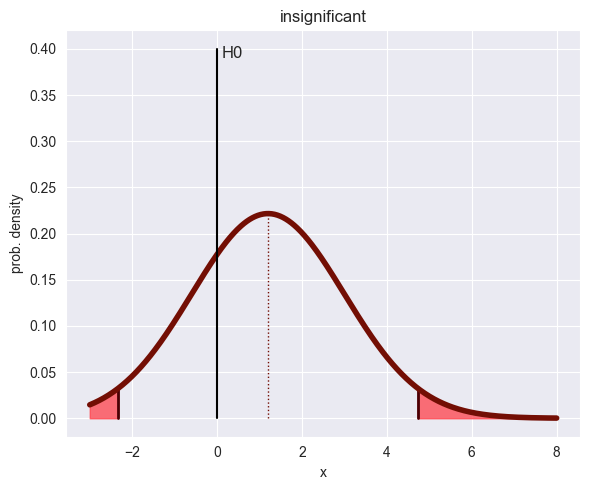

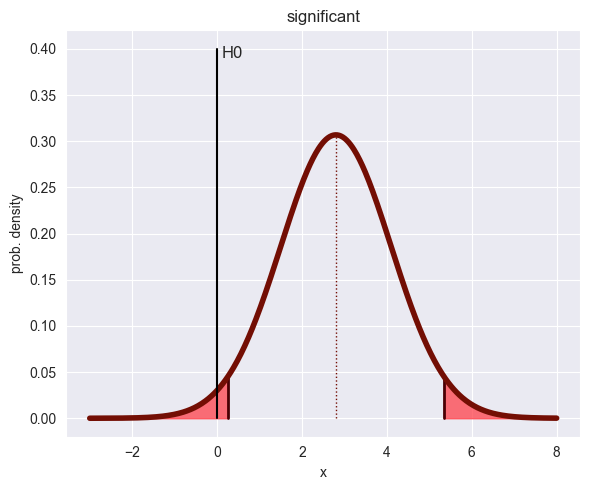

In [7]:
# NHST plots - individual figures for presentation alignment
nhst_configs = [
    {'mean': 1.2, 'std': 1.8, 'title': 'insignificant', 'filename': 'examples/nhst_part1.png'},
    {'mean': 2.8, 'std': 1.3, 'title': 'significant', 'filename': 'examples/nhst_part2.png'},
]

FROM, TO = -3, 8
height = 0.4

for config in nhst_configs:
    fig, ax = plt.subplots(figsize=(6, 5))
    
    nhst(ax, config['mean'], config['std'], FROM, TO, title=config['title'])
    
    # vertical line at H0
    ax.plot(*vline(0, height), c='k')
    ax.text(0.1, height - 0.01, 'H0', fontsize=12)
    
    ax.set_ylabel('prob. density')
    
    plt.tight_layout()
    plt.savefig(config['filename'], transparent=False, dpi=300)
    plt.show()

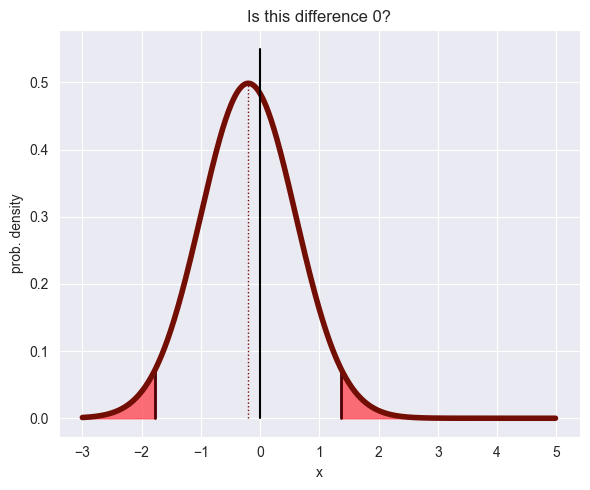

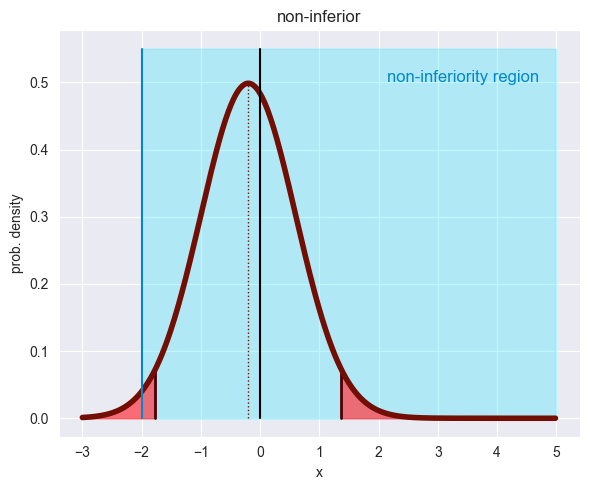

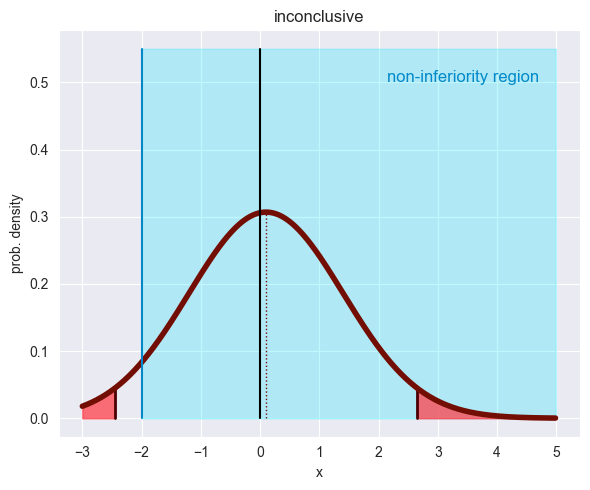

In [8]:
# Non-inferiority plots - individual figures for presentation alignment
noninf_configs = [
    {'mean': -0.2, 'std': 0.8, 'title': 'Is this difference 0?', 'filename': 'examples/non-inf_part1.png', 'show_region': False},
    {'mean': -0.2, 'std': 0.8, 'title': 'non-inferior', 'filename': 'examples/non-inf_part2.png', 'show_region': True},
    {'mean':  0.1, 'std': 1.3, 'title': 'inconclusive', 'filename': 'examples/non-inf_part3.png', 'show_region': True},
]

FROM, TO = -3, 5
height = 0.55
margin = -2

for config in noninf_configs:
    fig, ax = plt.subplots(figsize=(6, 5))
    
    # non-inferiority region (if applicable)
    if config['show_region']:
        fill = np.arange(margin, TO, 0.01)
        ax.fill_between(fill, [height] * len(fill), color='#06e7ff', alpha=0.25)
    
    nhst(ax, config['mean'], config['std'], FROM, TO, title=config['title'])
    
    # vertical line at H0
    ax.plot(*vline(0, height), c='k')
    
    # margin line and label (if showing region)
    if config['show_region']:
        ax.plot(*vline(margin, height), c='#0089ca')
        ax.text(TO - 0.3, height - 0.05, 'non-inferiority region',
                fontsize=12,
                color='#0089ca',
                horizontalalignment='right')
    
    ax.set_ylabel('prob. density')
    
    plt.tight_layout()
    plt.savefig(config['filename'], transparent=False, dpi=300)
    plt.show()